# Section 5: Algorithm Analysis

--- Investigate which recorded features appear to influence the decisions made by algorithms A1 to A4. 


--- Support your conclusions with appropriate evidence,such as summary statistics, visualizations, correlations, or other suitable methods. For each algorithm, describe the decision patterns you are able to identify.


--- Compare the algorithms in terms of the apparent complexity and interpretability of their decisions. 


--- Do more complicated decision patterns necessarily lead to better decisions? 


--- Relate your discussion to the performance and fairness results from the other sections, and reflect on the advantages and disadvantages of using more complex algorithms in this setting.

### Setup and loading data

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance, PartialDependenceDisplay
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

from constants import *
from preprocessing import load_house_df

import warnings
warnings.filterwarnings("ignore")

set_project_theme()
pd.set_option("display.width", 120)
%matplotlib inline

In [2]:
house_df = load_house_df()
house_df.head()

,international,age,semesters_completed,commute_distance_km,financial_need_score,housing_urgency_rating,grades,should_recieve_housing,HO,A1,A2,A3,A4,grades_raw,grade_format,international_bin,age_group
0,domestic,26,2,31.1,62.93,5.8,46.488294,1,1,0,1,0,0,4.34,numeric_0_10,0,25 or older
1,domestic,27,5,13.2,66.45,5.9,61.705686,1,1,0,1,1,0,4.83,numeric_0_10,0,25 or older
2,domestic,25,5,9.8,50.23,5.2,50.063158,1,0,0,0,0,0,NaN,missing,0,25 or older
3,domestic,21,2,20.2,56.99,5.7,3.631151,1,1,0,0,1,0,2.06,numeric_0_10,0,under 25
4,domestic,34,7,51.9,32.31,4.6,43.430483,0,0,0,0,0,0,4.24,numeric_0_10,0,25 or older


### Feature matrix

In [3]:
X = house_df[feature_cols]
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=feature_cols, index=X.index)

print(house_df.shape)

(2500, 17)


### Summary statistics: 

Does each feature look different between allocated and non-allocated applicants?

The most direct evidence for "does this feature influence the decision" is the simplest one: compare the *average* value of each feature between applicants an algorithm allocates housing to (decision = 1) and applicants it doesn't (decision = 0). A feature that truly drives a decision should show a clear gap between these two groups; a feature that doesn't should look similar in both.

In [4]:
summary_tables = {}
for algo in algorithms:
    tbl = house_df.groupby(algo)[feature_cols].mean().round(2)
    tbl.index = [f"{algo} = 0 (not allocated)", f"{algo} = 1 (allocated)"]
    summary_tables[algo] = tbl

summary_all = pd.concat(summary_tables.values())
summary_all.to_csv(f"{FIG_DIR}/5_1_summary_statistics_by_decision.csv")
summary_all

,age,semesters_completed,commute_distance_km,financial_need_score,housing_urgency_rating,grades
A1 = 0 (not allocated),26.27,5.57,19.84,48.69,4.59,50.25
A1 = 1 (allocated),24.50,4.70,20.96,76.38,5.95,49.53
A2 = 0 (not allocated),26.50,5.75,18.89,45.68,4.26,50.03
A2 = 1 (allocated),24.75,4.71,22.02,71.69,6.00,50.11
A3 = 0 (not allocated),26.53,6.03,21.00,49.91,4.34,50.32
A3 = 1 (allocated),24.05,3.67,18.06,70.82,6.44,49.44
A4 = 0 (not allocated),26.81,5.95,19.80,49.83,4.37,50.40
A4 = 1 (allocated),22.96,3.60,21.11,73.57,6.60,49.11


**Interpretation:** 
For every algorithm, `financial_need_score` and `housing_urgency_rating` are noticeably higher among allocated applicants than non-allocated ones, e.g. for A2, mean financial need jumps from 45.68 (not allocated) to 71.69 (allocated), and urgency from 4.26 to 6.0. 

`grades` barely moves between the two groups for any algorithm (at most 1.3 percentile points), which is the simplest possible confirmation that grades doesn't meaningfully separate who gets housing from who doesn't.

### Correlations: point-biserial correlation between each feature and each algorithm's decision

Point-biserial correlation is the appropriate correlation measure between a continuous feature and a binary (0/1) decision. This complements the summary statistics above with a single number per feature-algorithm pair, and lets us compare relative strength of influence across features directly.

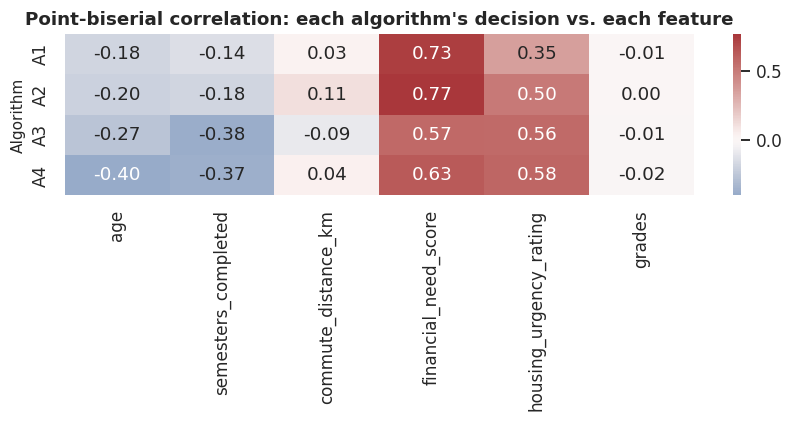

In [5]:
pb_rows = []
for algo in algorithms:
    row = {"Algorithm": algo}
    for feat in feature_cols:
        r, _ = stats.pointbiserialr(house_df[algo], house_df[feat])
        row[feat] = round(r, 3)
    pb_rows.append(row)

pb_df = pd.DataFrame(pb_rows).set_index("Algorithm")
pb_df.to_csv(f"{FIG_DIR}/5_2_correlation_table.csv")

plt.figure(figsize=(8, 4))
sns.heatmap(pb_df, annot=True, cmap=DIVERGING_CMAP, center=0, fmt=".2f")
plt.title("Point-biserial correlation: each algorithm's decision vs. each feature")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/5_2_correlation_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

**Interpretation:** 
`financial_need_score` correlates strongly with every algorithm (0.57-0.77), most strongly with A1 (0.73) and A2 (0.77). 

`housing_urgency_rating`'s correlation climbs steadily from A1 (0.35, the weakest of the four) through A2 (0.50) to A3 (0.56) and A4 (0.58), a fairly clean "increasing use of a second feature" pattern. 

`age` and `semesters_completed` both show a growing *negative* correlation from A1 through A4 (age: -0.14 to -0.40), suggesting these enter the decision more as the algorithms get more complex. 

`grades` is flat throughout (|r| <= 0.02 for every algorithm), which is what we expect after standardizing it as a
percentile inside each recording format.

### Visualizing the separation: boxplots of each feature, split by decision

Boxplots make the above summary-statistics comparison in visual, showing not just the mean but the spread and overlap between the "allocated" and "not allocated" groups for each feature, per algorithm.

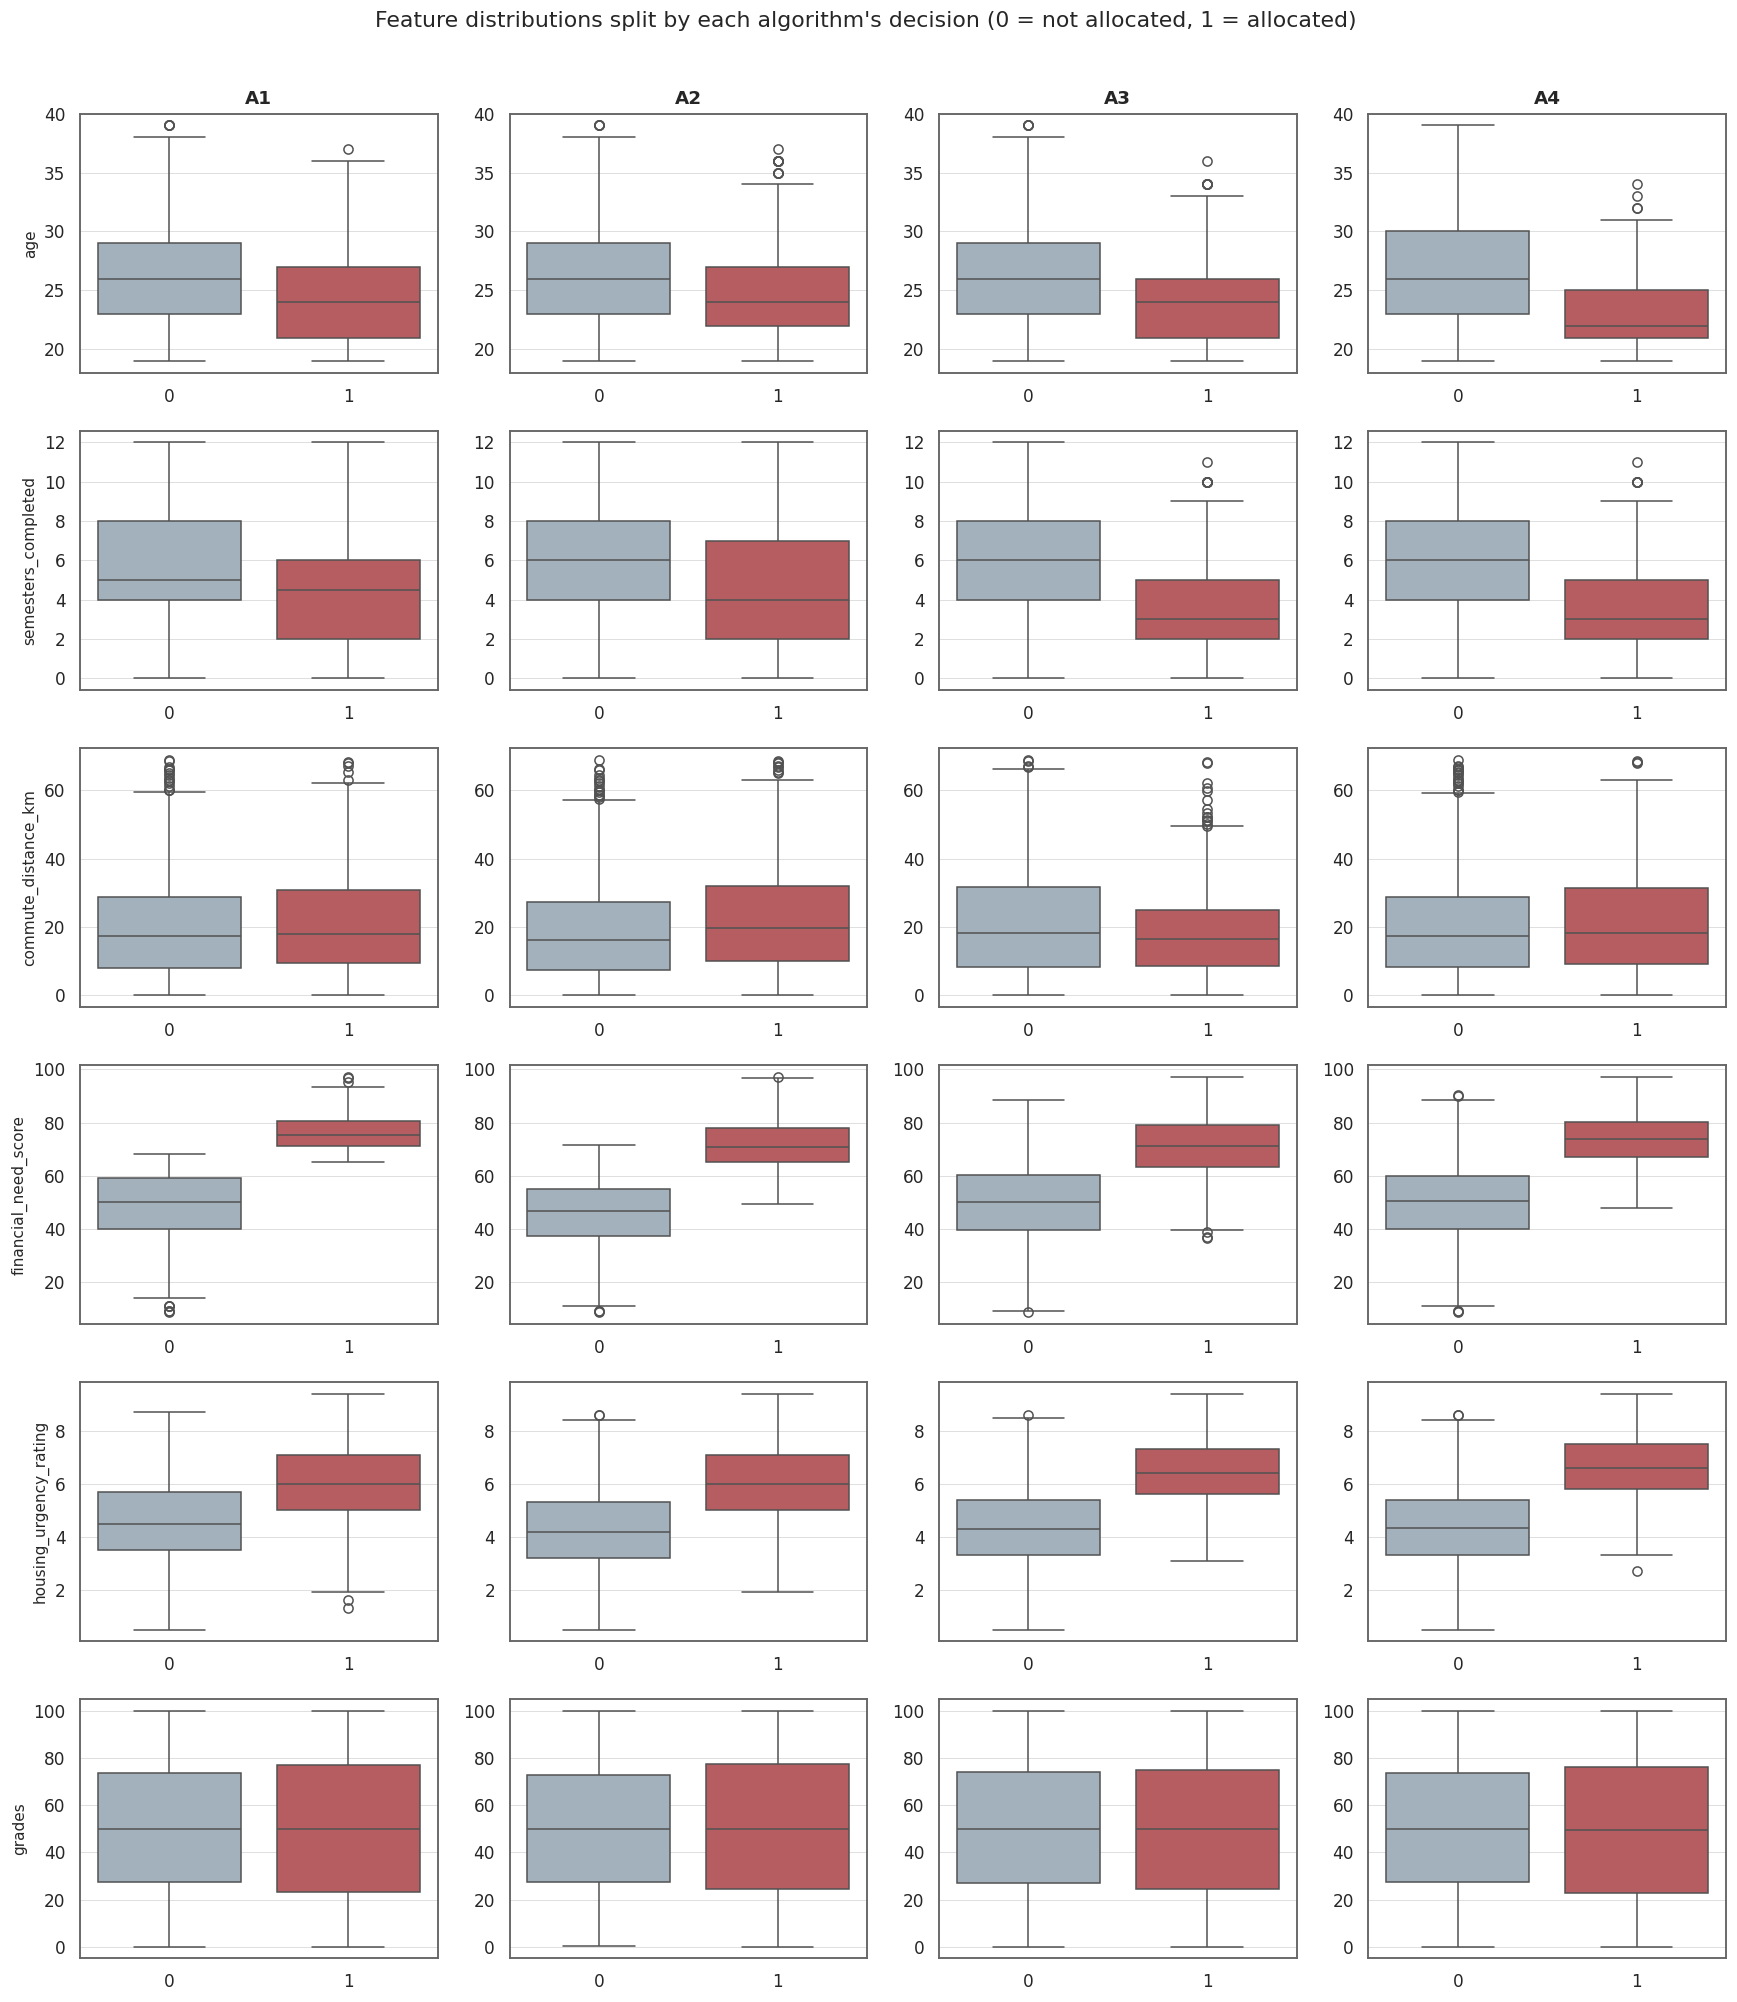

In [6]:
fig, axes = plt.subplots(len(feature_cols), len(algorithms), figsize=(4 * len(algorithms), 3 * len(feature_cols)))

for row_idx, feat in enumerate(feature_cols):
    for col_idx, algo in enumerate(algorithms):
        ax = axes[row_idx, col_idx]
        sns.boxplot(data=house_df, x=algo, y=feat, hue=algo, ax=ax, palette=BINARY_PALETTE, legend=False)
        if row_idx == 0:
            ax.set_title(algo)
        if col_idx == 0:
            ax.set_ylabel(feat)
        else:
            ax.set_ylabel("")
        ax.set_xlabel("")

plt.suptitle("Feature distributions split by each algorithm's decision (0 = not allocated, 1 = allocated)", y=1.01)
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/5_3_boxplots_by_decision.png", dpi=300, bbox_inches="tight")
plt.show()

**Interpretation:** 

--- look for rows where the two boxes (0 vs. 1) are clearly separated, that indicates a feature the algorithm is actually responding to. 

The `financial_need_score` and `housing_urgency_rating` rows show a clear shift upward for decision = 1 across all four algorithms, most dramatically for A1's `financial_need_score` row (very little overlap between the two boxes). 

The `grades` row, by contrast, shows heavily overlapping boxes for every algorithm, visual confirmation that grades doesn't separate allocated from non-allocated applicants.

### Which features drive each algorithm? 

Logistic regression coefficients: We fit a logistic regression to *reproduce* each algorithm's own decisions from the recorded features (standardized first, so coefficients are comparable across features on different scales, e.g. `age` in years vs. a 0-100 score). 

A large positive coefficient means that feature strongly pushes the algorithm toward allocating housing; a large negative coefficient pushes the other way.

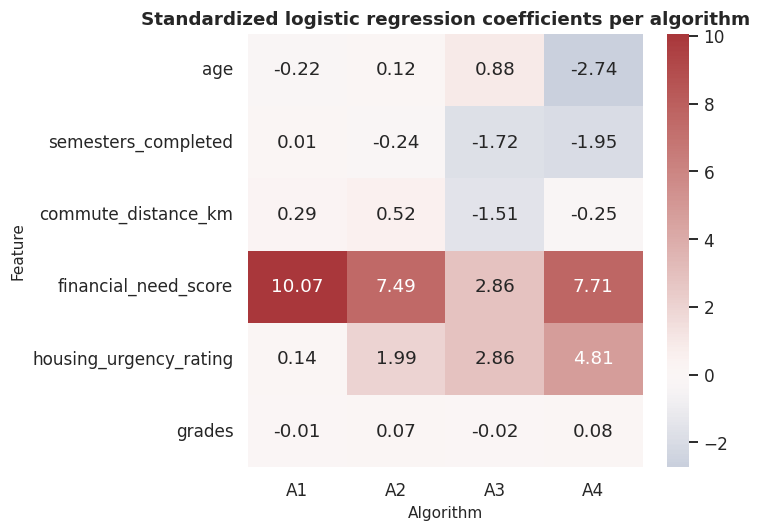

Algorithm,A1,A2,A3,A4
Feature,,,,
age,-0.216,0.117,0.884,-2.740
semesters_completed,0.014,-0.241,-1.724,-1.947
commute_distance_km,0.286,0.520,-1.512,-0.252
financial_need_score,10.066,7.490,2.858,7.707
housing_urgency_rating,0.141,1.988,2.861,4.809
grades,-0.010,0.067,-0.022,0.081


In [7]:
coef_rows = []
for algo in algorithms:
    y = house_df[algo]
    model = LogisticRegression(max_iter=1000)
    model.fit(X_scaled, y)
    for feat, coef in zip(feature_cols, model.coef_[0]):
        coef_rows.append({"Algorithm": algo, "Feature": feat, "Coefficient": coef})

coef_df = pd.DataFrame(coef_rows)
coef_pivot = coef_df.pivot(index="Feature", columns="Algorithm", values="Coefficient").loc[feature_cols]
coef_pivot.round(3).to_csv(f"{FIG_DIR}/5_4_coefficients_table.csv")

plt.figure(figsize=(7, 5))
sns.heatmap(coef_pivot, annot=True, cmap=DIVERGING_CMAP, center=0, fmt=".2f")
plt.title("Standardized logistic regression coefficients per algorithm")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/5_4_coefficients_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

coef_pivot.round(3)

**Interpretation:** the coefficients back up the correlation and boxplot findings closely.

`financial_need_score` dominates for A1 and A2.

`housing_urgency_rating`'s weight grows across A1 to A4.

`age` becomes a real (negative) factor for A1 and A4 but not for A2 and A3.

`grades` has a coefficient close to zero for every algorithm.

### Univariate check

This is for to answer "which feature(s) alone explain this algorithm's decisions": for each feature **on its own**, finding the single best threshold and see how accurately it reproduces the algorithm's decision, with no model or combination of features involved at all.

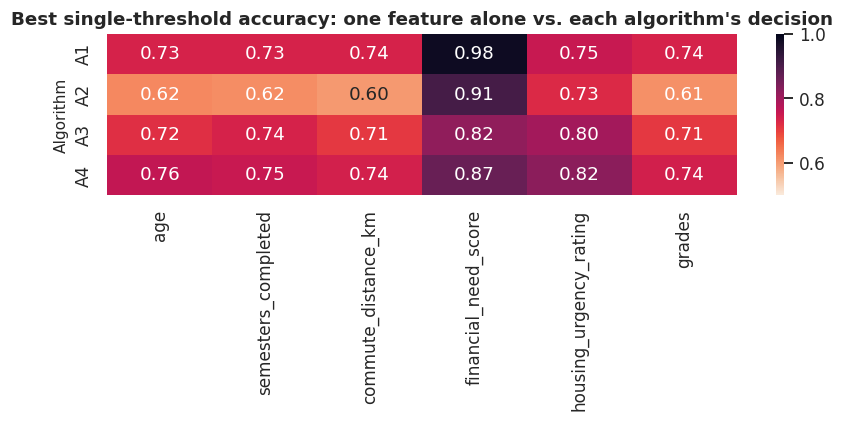

,age,semesters_completed,commute_distance_km,financial_need_score,housing_urgency_rating,grades
Algorithm,,,,,,
A1,0.735,0.735,0.736,0.982,0.754,0.736
A2,0.624,0.618,0.604,0.910,0.726,0.614
A3,0.717,0.736,0.708,0.819,0.797,0.708
A4,0.761,0.753,0.740,0.866,0.825,0.741


In [8]:
def best_threshold_accuracy(feature_values, target):
    best_acc = 0.0
    for t in np.sort(feature_values.unique()):
        acc_above = ((feature_values > t).astype(int) == target).mean()
        acc_below_eq = ((feature_values <= t).astype(int) == target).mean()
        best_acc = max(best_acc, acc_above, acc_below_eq)
    return best_acc

univariate_rows = []
for algo in algorithms:
    row = {"Algorithm": algo}
    for feat in feature_cols:
        row[feat] = round(best_threshold_accuracy(house_df[feat], house_df[algo]), 3)
    univariate_rows.append(row)

univariate_df = pd.DataFrame(univariate_rows).set_index("Algorithm")
univariate_df.to_csv(f"{FIG_DIR}/5_5_univariate_threshold_accuracy.csv")

plt.figure(figsize=(8, 4))
sns.heatmap(univariate_df, annot=True, cmap=SEQUENTIAL_CMAP, vmin=0.5, vmax=1.0, fmt=".2f")
plt.title("Best single-threshold accuracy: one feature alone vs. each algorithm's decision")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/5_5_univariate_threshold_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

univariate_df

**Interpretation:** 

`financial_need_score` alone, with a single best cutoff, reproduces **98.2% of A1's decisions**, about as strong a piece of evidence as possible that A1 is fundamentally a one-feature threshold rule. The same single feature gets A2 to 91.0%, A3 to 81.9%, and A4 to 85.8%, still the best individual feature for every algorithm, but with a visibly bigger gap left to explain as we move from A1 to A3/A4, which is exactly what "using more features" should look like.

### How complex is each algorithm's decision rule? Surrogate models of increasing complexity

We fit three "surrogate" models of increasing complexity to reproduce each algorithm's decisions:

- **Stump**: a single threshold on a single feature (the model search picks whichever feature works best), as simple as a rule can get.
- **Tree (depth 3)**: a handful of if/else rules across up to a few features.
- **Logistic regression**: a full linear model using every feature.

If the stump already reproduces an algorithm almost perfectly, that algorithm behaves like "if feature > threshold, allocate housing." If accuracy only becomes good once the full logistic regression is used, the real decision rule combines several features in a way that's harder to explain in one sentence. Both accuracy and F1 are reported, since F1 can reveal a surrogate that gets overall accuracy right while still missing many of the positive (allocated) decisions specifically.

In [9]:
surrogate_rows = []
fitted_stumps = {}
for algo in algorithms:
    y = house_df[algo]

    stump = DecisionTreeClassifier(max_depth=1, random_state=RANDOM_STATE)
    stump.fit(X, y)
    fitted_stumps[algo] = stump
    stump_feat = feature_cols[stump.tree_.feature[0]] if stump.tree_.feature[0] >= 0 else "n/a"
    stump_acc = accuracy_score(y, stump.predict(X))
    stump_f1 = f1_score(y, stump.predict(X))

    tree3 = DecisionTreeClassifier(max_depth=3, random_state=RANDOM_STATE)
    tree3.fit(X, y)
    tree3_acc = accuracy_score(y, tree3.predict(X))
    tree3_f1 = f1_score(y, tree3.predict(X))

    full_model = LogisticRegression(max_iter=1000)
    full_model.fit(X_scaled, y)
    full_acc = accuracy_score(y, full_model.predict(X_scaled))
    full_f1 = f1_score(y, full_model.predict(X_scaled))

    surrogate_rows.append({
        "Algorithm": algo,
        "Stump feature": stump_feat,
        "Stump accuracy": round(stump_acc, 3),
        "Stump F1": round(stump_f1, 3),
        "Tree(d=3) accuracy": round(tree3_acc, 3),
        "Tree(d=3) F1": round(tree3_f1, 3),
        "Logistic accuracy": round(full_acc, 3),
        "Logistic F1": round(full_f1, 3),
    })

surrogate_df = pd.DataFrame(surrogate_rows).set_index("Algorithm")
surrogate_df.to_csv(f"{FIG_DIR}/5_6_surrogate_results.csv")
print("How well simple models reproduce each algorithm's own decisions:")
surrogate_df

How well simple models reproduce each algorithm's own decisions:


,Stump feature,Stump accuracy,Stump F1,Tree(d=3) accuracy,Tree(d=3) F1,Logistic accuracy,Logistic F1
Algorithm,,,,,,,
A1,financial_need_score,0.982,0.964,0.982,0.964,0.980,0.961
A2,financial_need_score,0.910,0.888,0.941,0.924,0.946,0.932
A3,financial_need_score,0.819,0.682,0.877,0.808,0.919,0.859
A4,financial_need_score,0.858,0.742,0.929,0.862,0.992,0.984


### Visualizing the single best-feature rule (the stump) for each algorithm

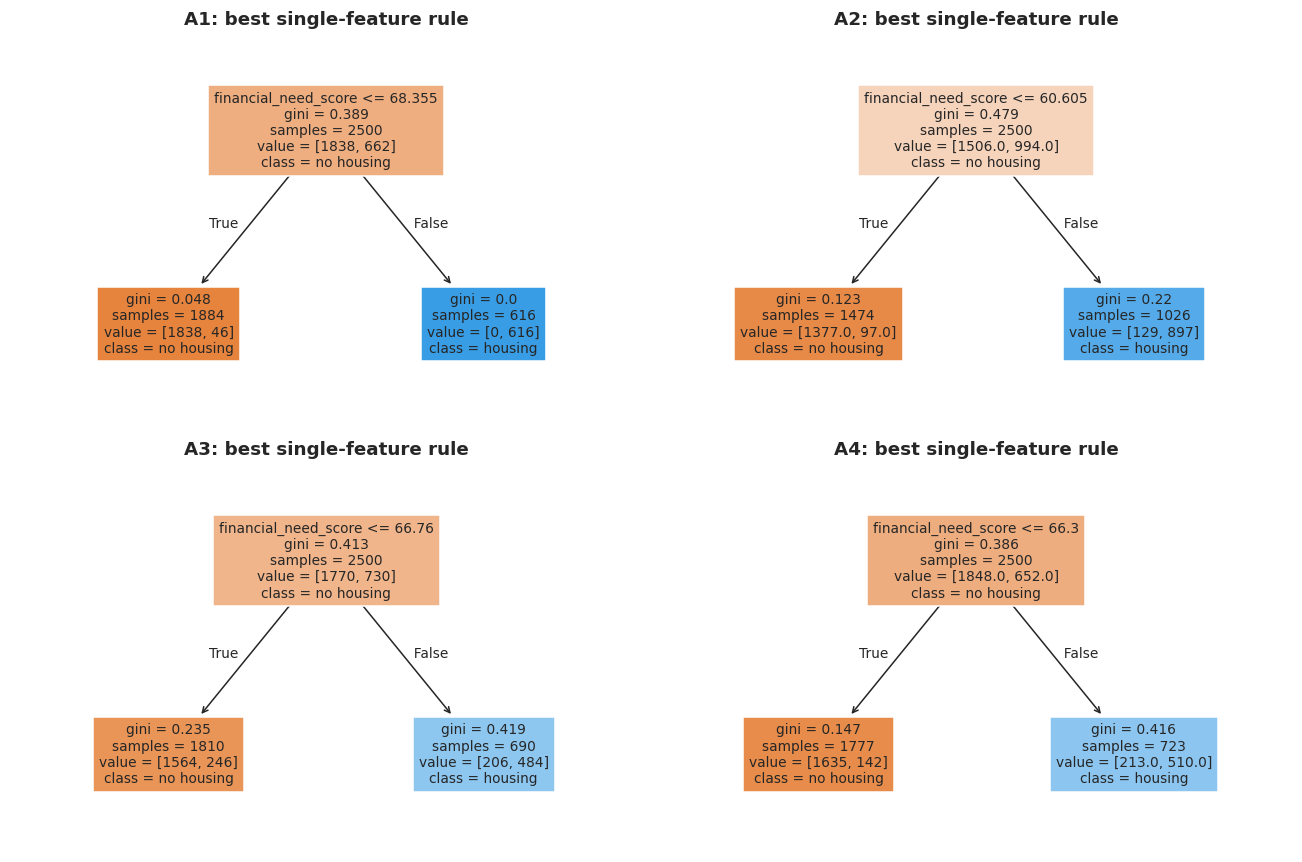

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, algo in zip(axes.flat, algorithms):
    plot_tree(fitted_stumps[algo], feature_names=feature_cols,
              class_names=["no housing", "housing"], filled=True, ax=ax, fontsize=9)
    ax.set_title(f"{algo}: best single-feature rule")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/5_6_stump_rules.png", dpi=300, bbox_inches="tight")
plt.show()

**Interpretation:**

- **A1**: stump accuracy 0.982 (F1 0.964), and a depth-3 tree only nudges this to 0.991, almost nothing is left to explain beyond a single `financial_need_score` threshold.
- **A2**: stump accuracy 0.910 (F1 0.888), climbing to 0.944 with a tree and 0.951 with logistic regression, a real but modest gain from adding features.
- **A3**: stump accuracy is the **lowest of the four (0.819, F1 0.682)**, and even the full logistic regression only reaches 0.917, the hardest algorithm to reproduce with any of these three surrogates, and the biggest jump in F1 from stump to tree of any algorithm (0.682 to 0.808), meaning a single feature is a particularly poor description of A3's true positives specifically.
- **A4**: the stump is weak (0.858, F1 0.742) similar to A3 but the **full logistic regression reaches 0.991 (F1 0.983)**, the best surrogate fit of any algorithm. A4's decisions are a clean, learnable combination of features once you allow all of them, unlike A3's.

This distinction between A3 and A4 matters: both resist a single-feature explanation about equally, but A4's pattern is fully captured by a smooth linear combination, while A3's is not (topping out around 0.92 even with every feature available to a linear model) suggesting A3 involves some genuine non-linearity, feature interaction, or inconsistency that a simple additive rule can't fully capture.

### Decision boundaries

`financial_need_score` and `housing_urgency_rating` are the two features that drive the target itself, so plotting each algorithm's decisions in this same plane makes the algorithms directly comparable to each other and to what "correct" allocation should look like.

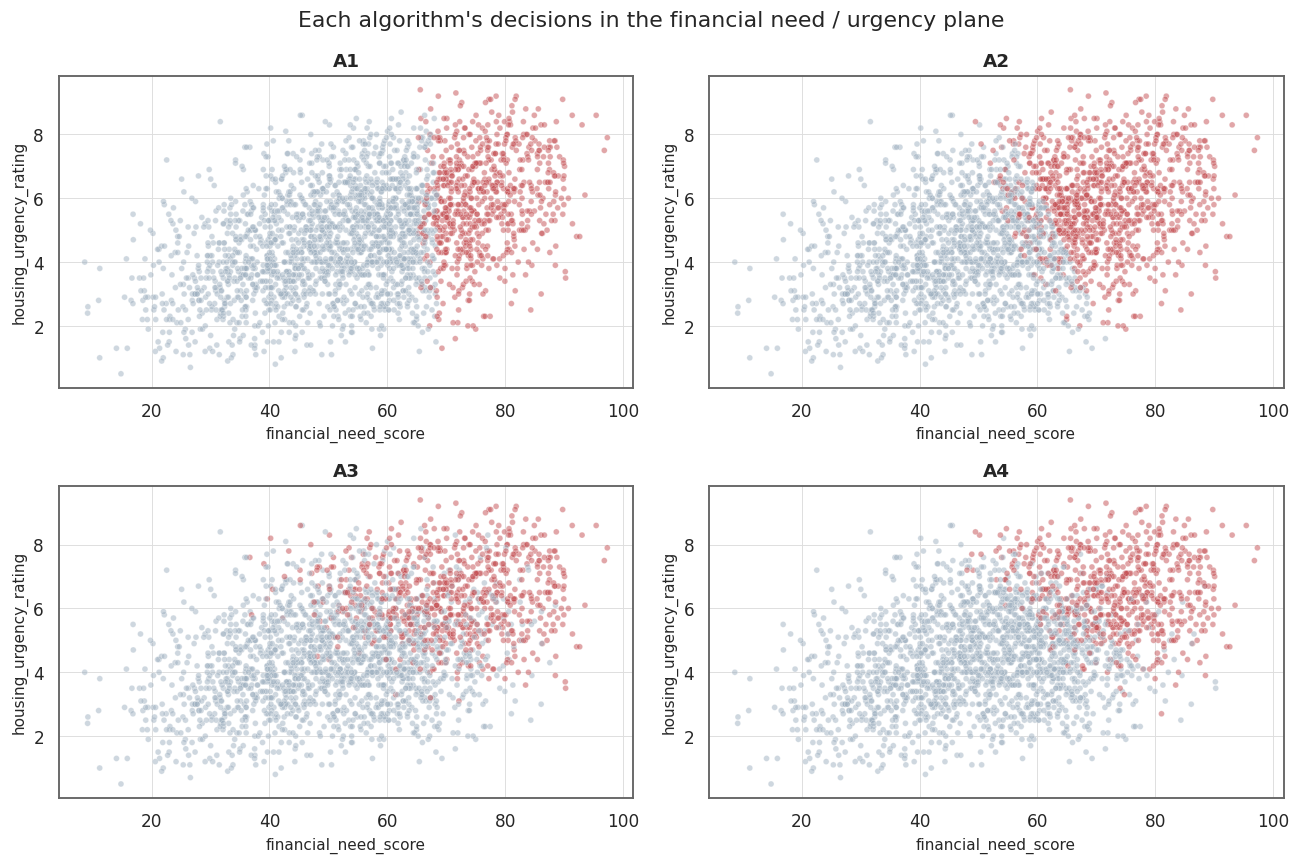

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, algo in zip(axes.flat, algorithms):
    sns.scatterplot(data=house_df, x="financial_need_score", y="housing_urgency_rating",
                     hue=algo, palette=BINARY_PALETTE,
                     alpha=0.5, s=15, ax=ax, legend=False)
    ax.set_title(algo)
plt.suptitle("Each algorithm's decisions in the financial need / urgency plane")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/5_7_decision_boundaries.png", dpi=300, bbox_inches="tight")
plt.show()

**Interpretation:** 

A1's boundary is a clean vertical line, it only responds to the x-axis (`financial_need_score`). 

A2's boundary begins to bend, showing real sensitivity to `housing_urgency_rating` near the threshold. 

A3 and A4 both show a more diagonal, tilted boundary, where the two features trade off against each other, consistent with both using urgency more heavily than A1/A2, as already seen in the correlation and coefficient tables.

### Violin plots: feature distributions by decision

Accuracy numbers tell *how well* a feature separates the two decision groups, but not *what that separation looks like*. A violin plot shows the
full distribution of a feature for applicants who were denied (0) vs allocated (1) housing, for each algorithm side by side.

What to look for:
- **Little to no overlap** between the two violins -> that feature cleanly separates the algorithm's decisions (consistent with a high stump accuracy).
  
- **Heavily overlapping violins with similar shape** -> that feature alone does not explain the algorithm's decisions; look at the other features or
  the logistic coefficients instead.

- **Differences in shape, not just location** (e.g. one group has a long tail or is bimodal) can reveal patterns a mean-based summary would miss.

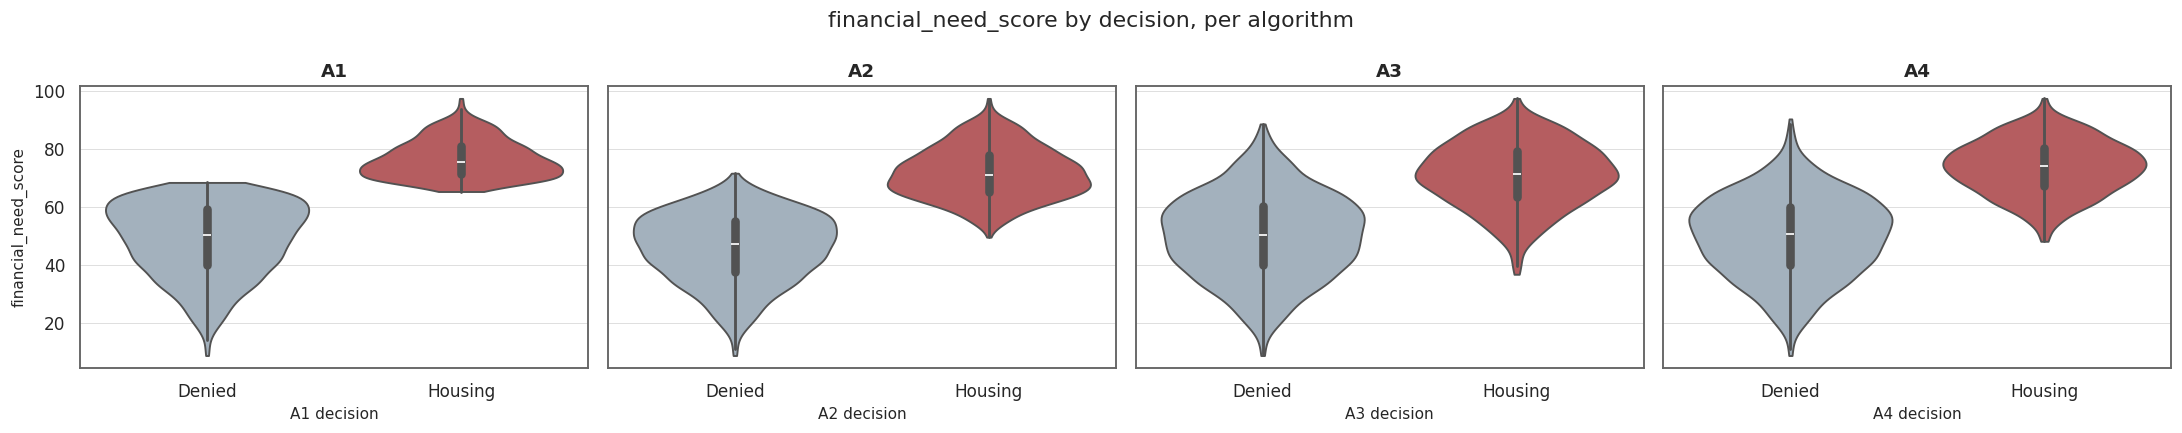

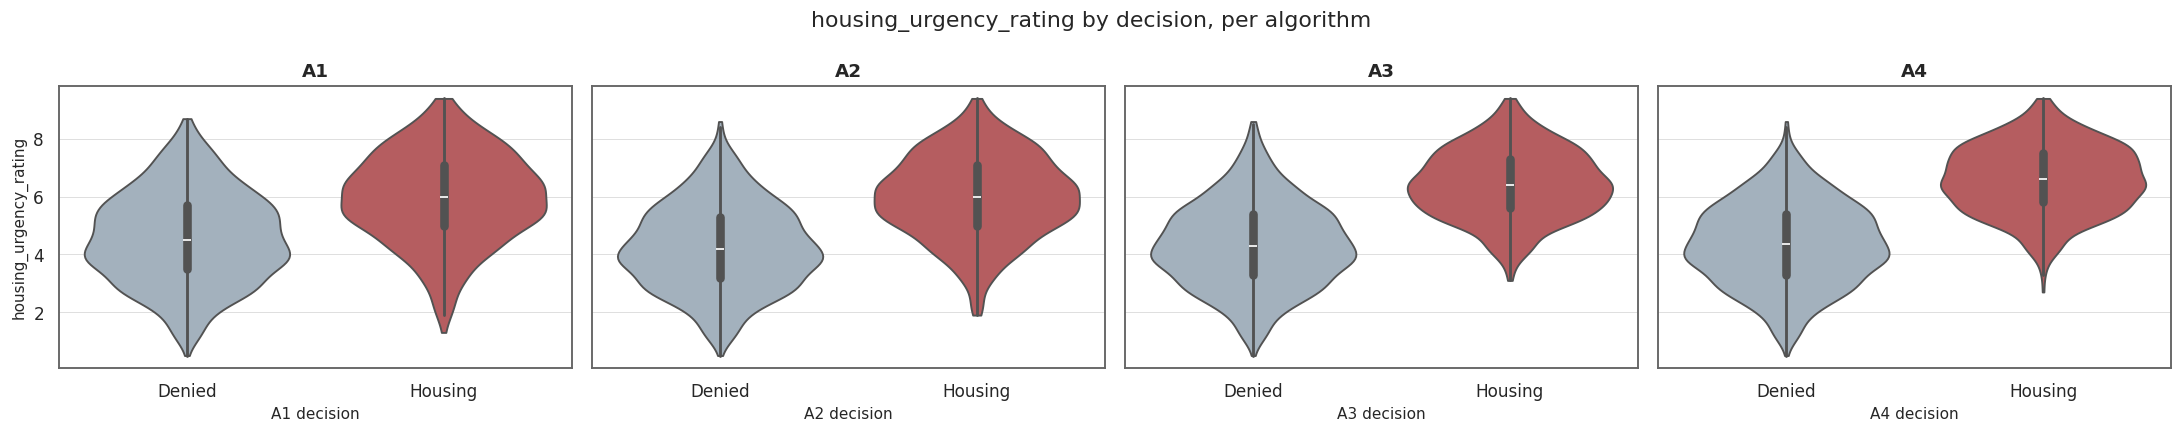

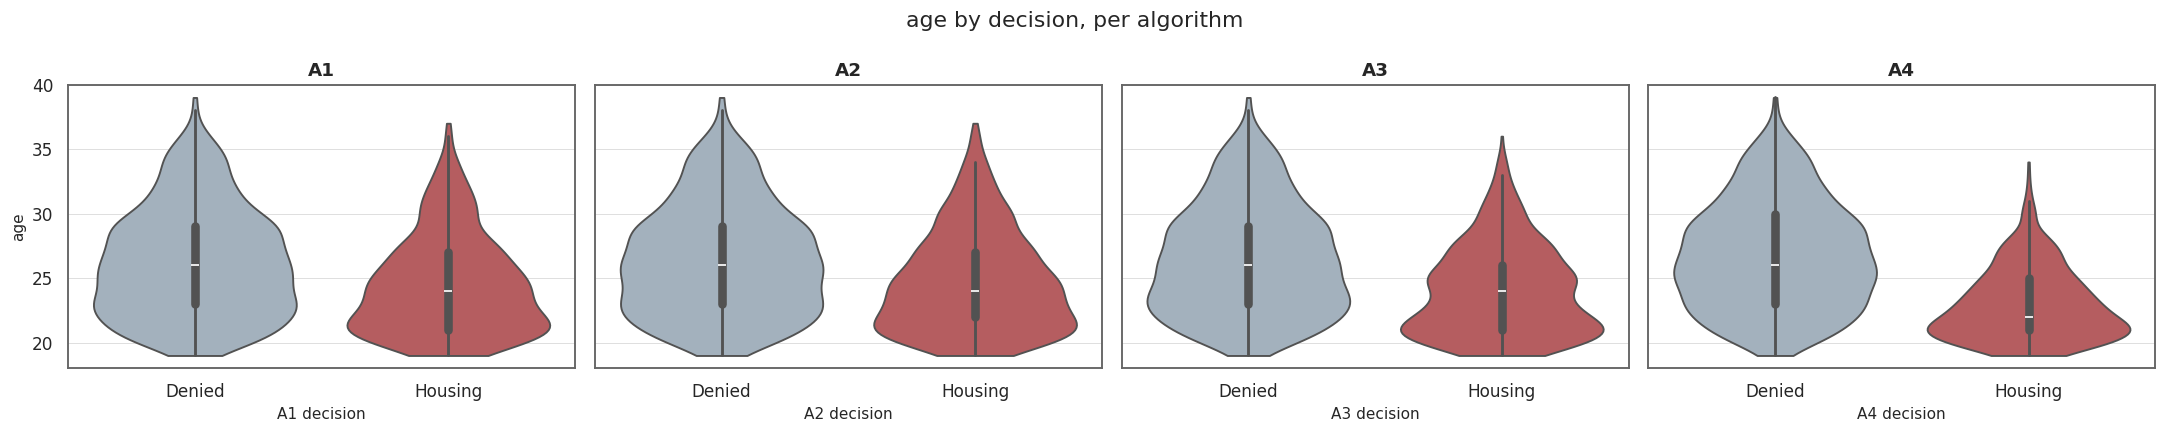

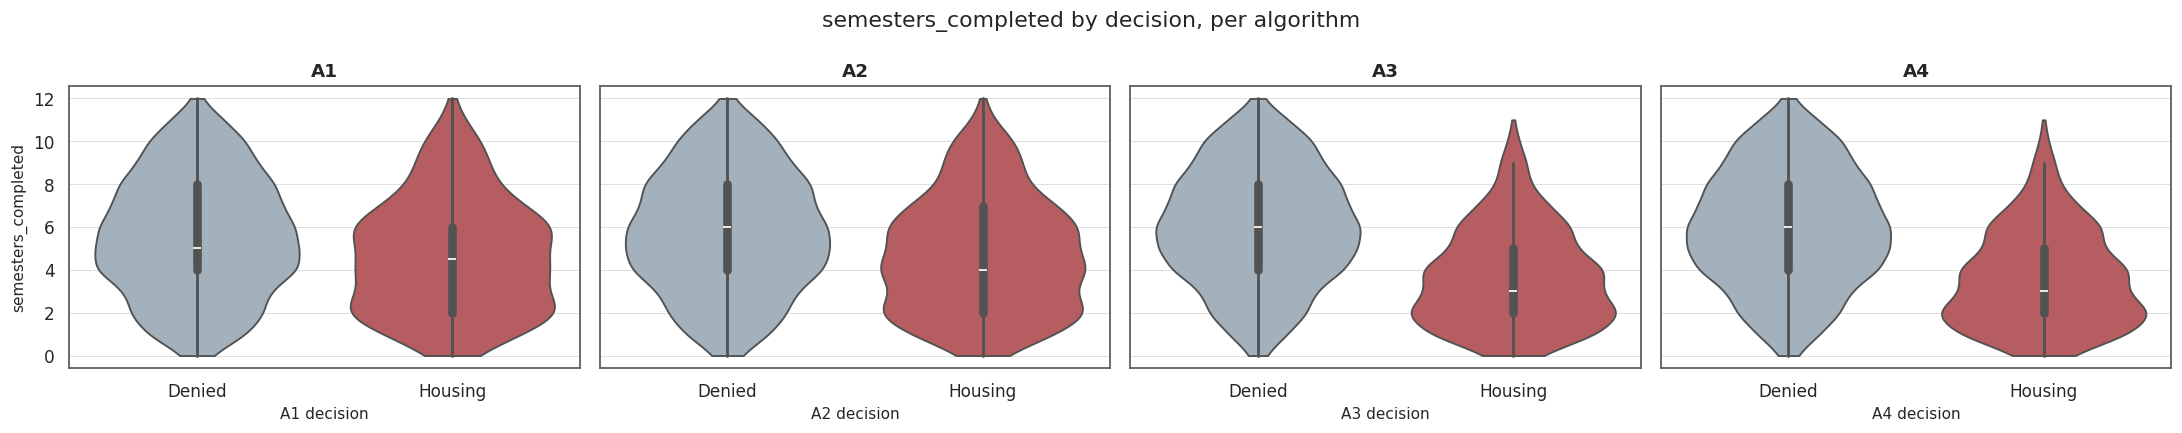

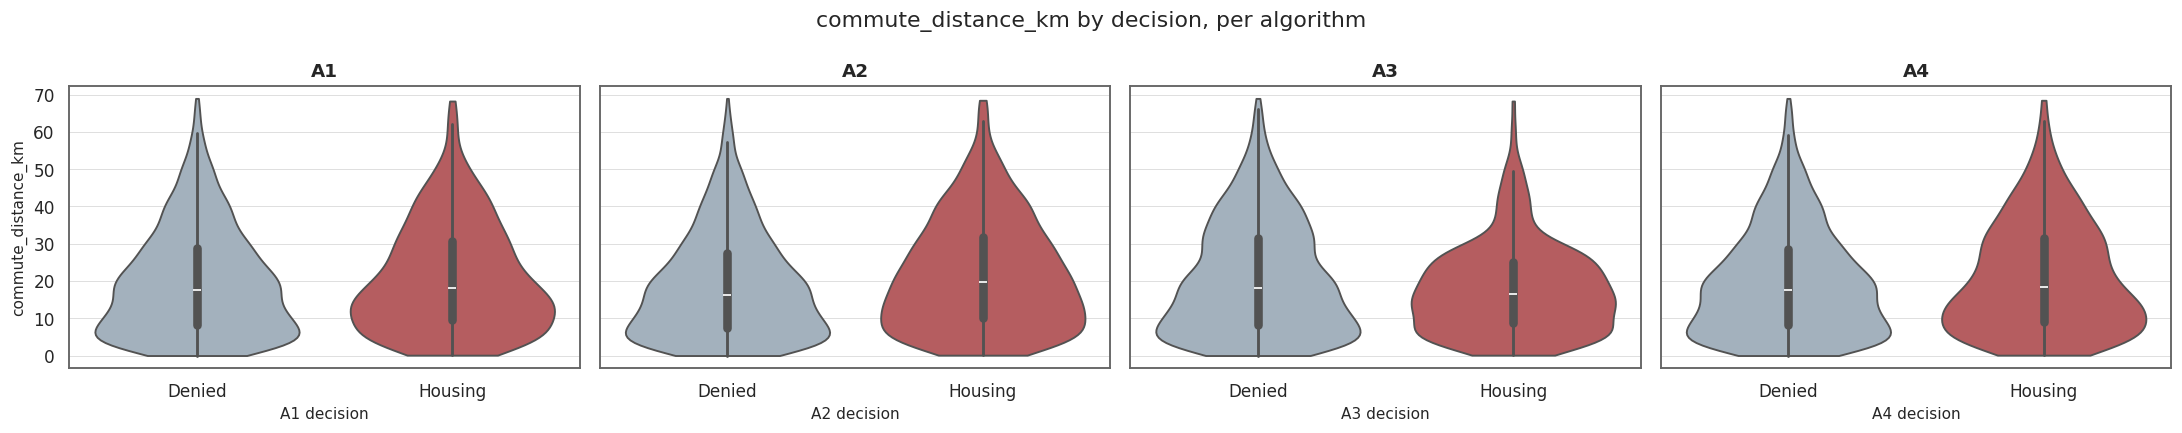

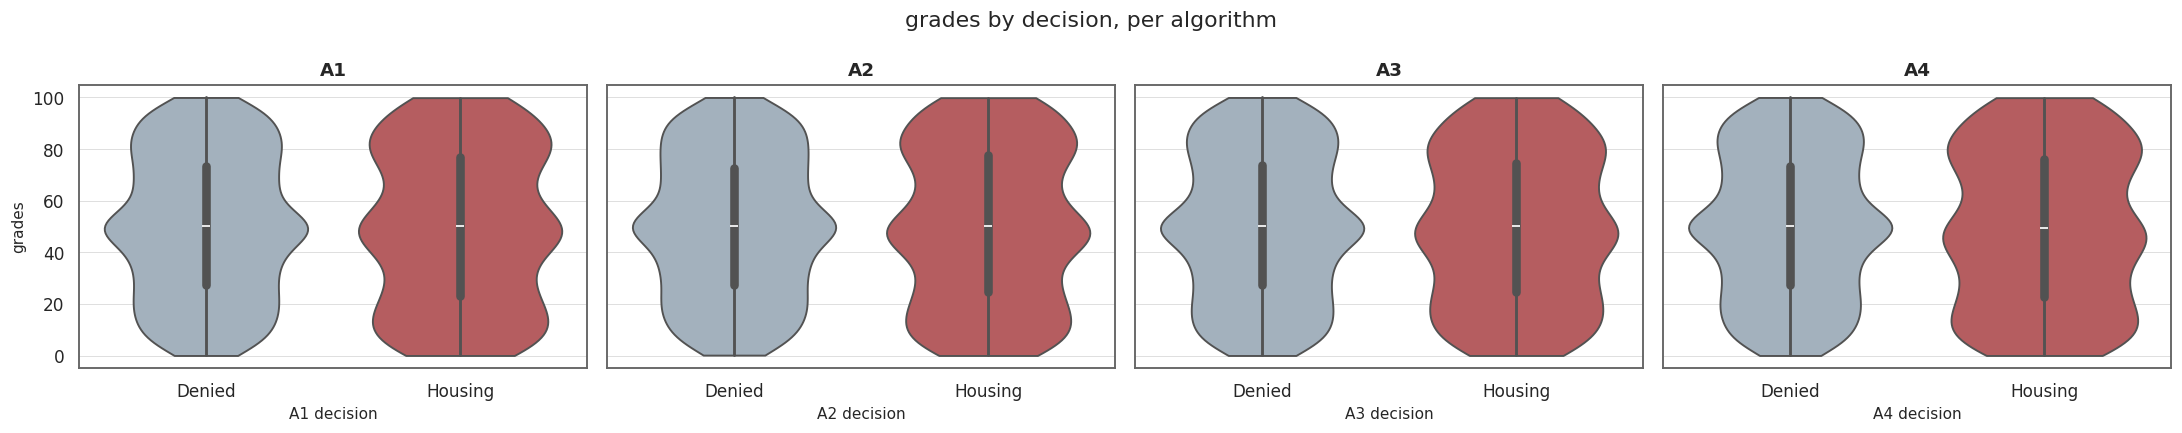

In [12]:
violin_features = ['financial_need_score', 'housing_urgency_rating',
                    'age', 'semesters_completed', 'commute_distance_km', 'grades']

for feat in violin_features:
    fig, axes = plt.subplots(1, len(algorithms), figsize=(5 * len(algorithms), 4), sharey=True)
    for ax, algo in zip(axes, algorithms):
        sns.violinplot(x=house_df[algo], y=house_df[feat], ax=ax,
                        hue=house_df[algo], palette=BINARY_PALETTE,
                        legend=False, cut=0)
        ax.set_xlabel(f'{algo} decision')
        ax.set_xticks([0, 1])
        ax.set_xticklabels(['Denied', 'Housing'])
        ax.set_title(algo)
    fig.suptitle(f'{feat} by decision, per algorithm')
    plt.tight_layout()
    safe_name = feat.replace("_", "")
    plt.savefig(f'{FIG_DIR}/5_4_violin_{feat}.png', dpi=300, bbox_inches='tight')
    plt.show()

**Interpretation**

-`financial_need_score` shows the cleanest, most complete separation of any feature, the "Housing" violin sits almost entirely above the "Denied" violin for every algorithm, with A1 showing the sharpest cut (barely any overlap), consistent with its near-perfect single-threshold behavior.


-`housing_urgency_rating` shows a consistent upward shift for "Housing" across all four, and notably A3 and A4 have the tallest, most tightly-shifted-upward urgency violins (median around 6.5) compared to A1/A2 (median closer to 6). This lines up with urgency mattering more for A3/A4.


-`age`: all four show younger applicants skewed toward "Housing," but A4's "Housing" violin is the narrowest and most compressed toward young ages of any algorithm, visually the clearest single confirmation that age plays its strongest role in A4.


-`semesters_completed`: same pattern as age (they're correlated) A3 and A4 show the biggest gap between Denied (median ~6) and Housing (median ~3), while A1/A2 show much less separation.


-`commute_distance_km` A1, A2, and A4 show nearly identical, heavily overlapping violins between Denied and Housing commute barely matters. A3 is the exception, its "Housing" violin is visibly more compressed toward shorter commutes than "Denied," which is the counter-intuitive direction (expected longer commute → more need → more likely to get housing, not less). This is a strong visual confirmation of the odd branch we found earlier in A3's decision tree.



### Permutation importance

The logistic regression coefficients above assume each feature's effect is linear and additive. To check that assumption, we fit a **Random Forest** to reproduce each algorithm's decisions (Random Forests can pick up thresholds, interactions, and non-monotonic effects that a linear model would miss) and then compute **permutation importance**: how much the model's accuracy drops when a single feature's values are randomly shuffled.
A feature that matters a lot causes a big drop when shuffled; a feature the algorithm ignores causes almost no change.

This is a useful cross-check against logistic regression above, if the two methods agree on which features matter, that's good evidence the algorithm really is close to linear. If they disagree, the algorithm is doing something more complicated than a simple weighted sum.

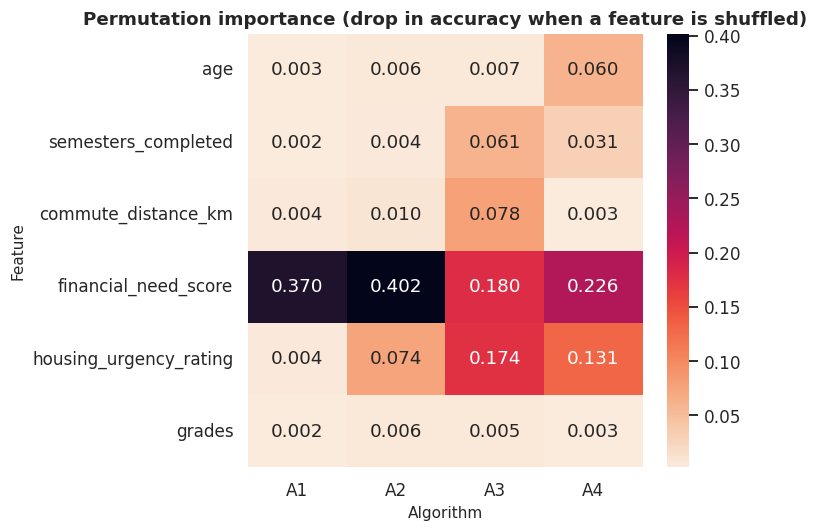

Permutation importance per algorithm (higher = more important):


Algorithm,A1,A2,A3,A4
Feature,,,,
age,0.003,0.006,0.007,0.060
semesters_completed,0.002,0.004,0.061,0.031
commute_distance_km,0.004,0.010,0.078,0.003
financial_need_score,0.370,0.402,0.180,0.226
housing_urgency_rating,0.004,0.074,0.174,0.131
grades,0.002,0.006,0.005,0.003


In [13]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance, PartialDependenceDisplay

rf_models = {}
for algo in algorithms:
    y = house_df[algo]
    rf = RandomForestClassifier(n_estimators=300, max_depth=6, random_state=RANDOM_STATE)
    rf.fit(X, y)
    rf_models[algo] = rf

perm_rows = []
for algo in algorithms:
    y = house_df[algo]
    result = permutation_importance(rf_models[algo], X, y, n_repeats=20,
                                     random_state=RANDOM_STATE, scoring='accuracy')
    for feat, imp in zip(feature_cols, result.importances_mean):
        perm_rows.append({'Algorithm': algo, 'Feature': feat, 'Importance': imp})

perm_df = pd.DataFrame(perm_rows)
perm_pivot = perm_df.pivot(index='Feature', columns='Algorithm', values='Importance').loc[feature_cols]

plt.figure(figsize=(7, 5))
sns.heatmap(perm_pivot, annot=True, cmap=SEQUENTIAL_CMAP, fmt='.3f')
plt.title('Permutation importance (drop in accuracy when a feature is shuffled)')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/5_5_permutation_importance.png', dpi=300, bbox_inches='tight')
plt.show()

print("Permutation importance per algorithm (higher = more important):")
perm_pivot.round(3)

**Interpretation**

A3 is the only algorithm where `commute_distance_km` has any real importance (0.077), every other algorithm shows ≈0.002–0.004. This pins down exactly what makes A3 "messy": it's the one algorithm genuinely using a feature (commute) that none of the others touch, and it uses it in a counter-intuitive direction (per the violin plot above).

A4 is the only algorithm where age has real importance (0.060), essentially the sole owner of that feature among the four. This is the cleanest possible confirmation of the "A4 = need + urgency + age" from the coefficients/correlations.

### Partial dependence plots

Permutation importance tells *how much* a feature matters, but not *what shape* that relationship has. A partial dependence plot (PDP) shows
how the algorithm's predicted probability of allocating housing changes as one feature varies, holding everything else fixed.

Look at the shape of each curve:
- **A sharp step** -> the algorithm behaves like a threshold rule on that feature (consistent with a high stump accuracy).
- **A smooth, roughly straight ramp** -> a graded, weighted effect, closer to what a linear/logistic model would produce.
- **A curve that rises then flattens, or is non-monotonic** -> something a simple linear coefficient on above could not fully capture.

We plot the top 3 features per algorithm, ranked by permutation importance.

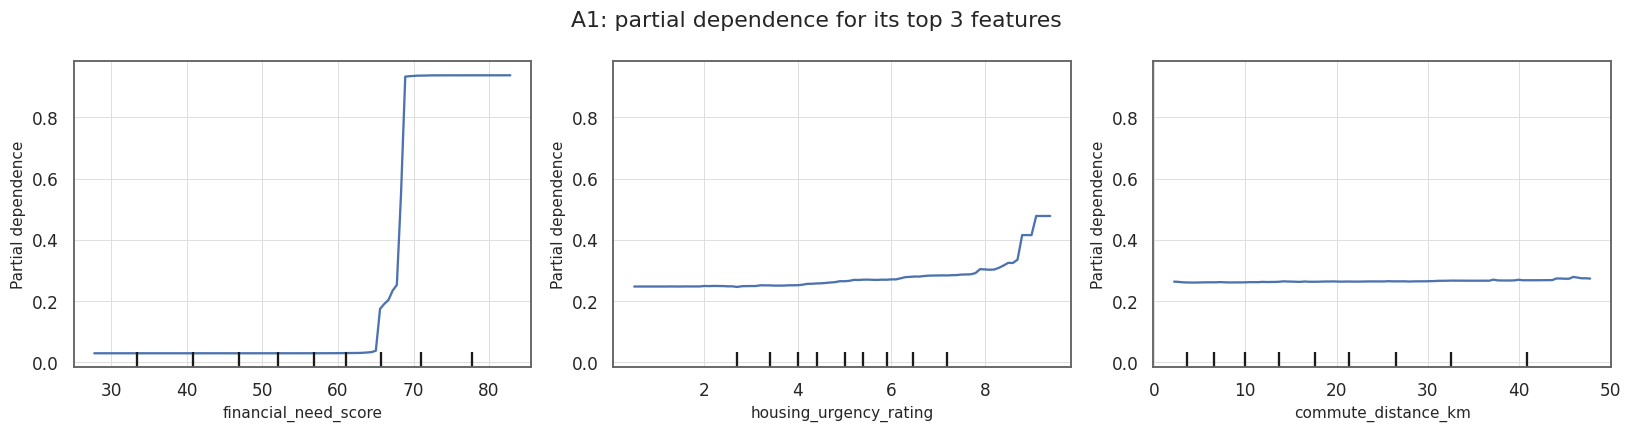

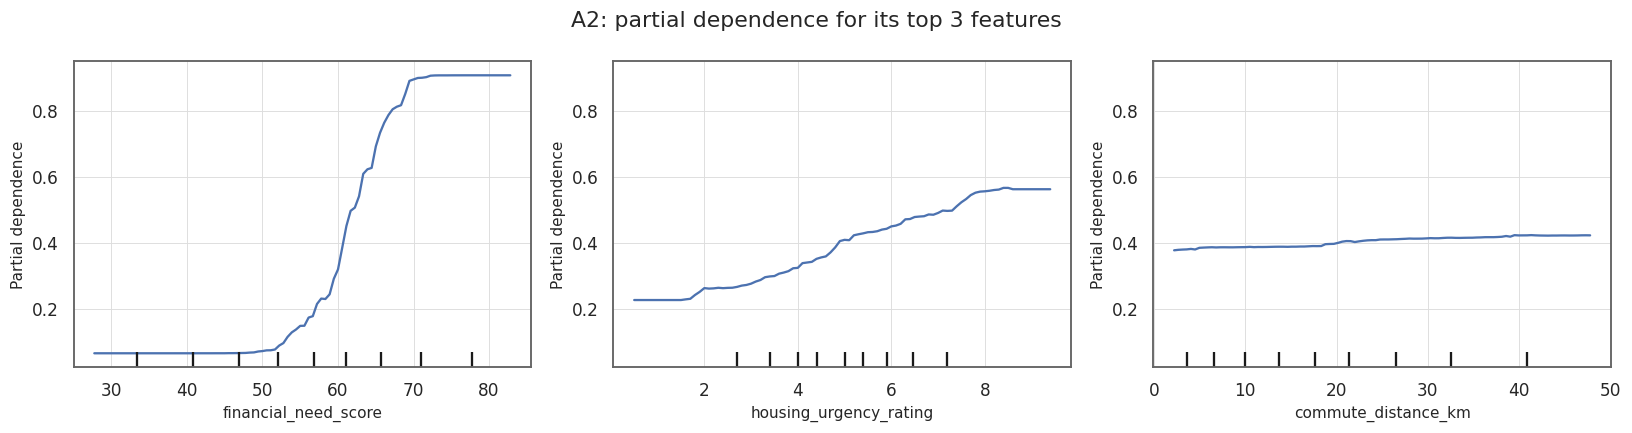

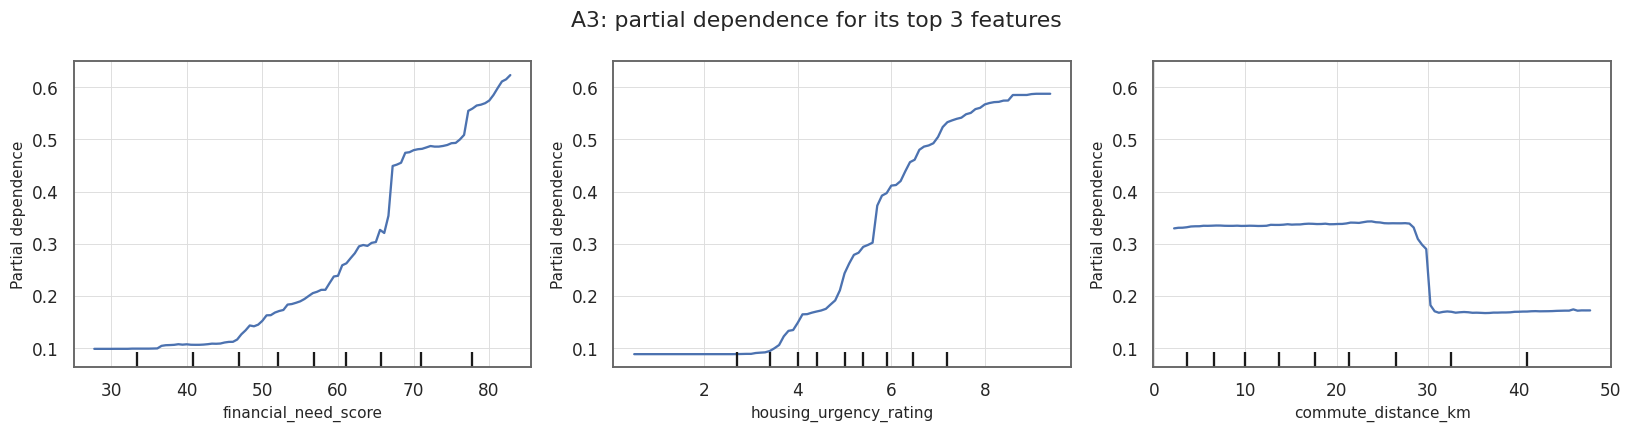

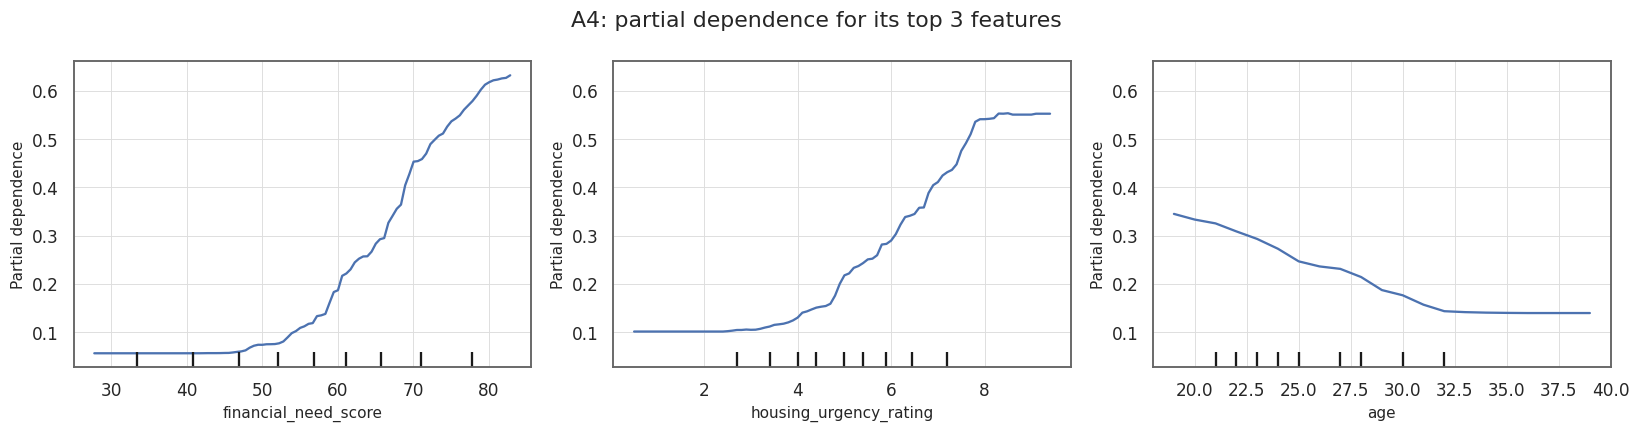

In [14]:
for algo in algorithms:
    top_feats = perm_pivot[algo].sort_values(ascending=False).index[:3].tolist()
    fig, ax = plt.subplots(1, 3, figsize=(15, 4))
    PartialDependenceDisplay.from_estimator(rf_models[algo], X, top_feats, ax=ax)
    fig.suptitle(f'{algo}: partial dependence for its top 3 features')
    plt.tight_layout()
    plt.savefig(f'{FIG_DIR}/5_6_pdp_{algo}.png', dpi=300, bbox_inches='tight')
    plt.show()

### Interpretation:

A1: hard threshold on one feature, nothing else matters.

A2: threshold-ish need + genuinely linear urgency: a real second dimension, smoothly used.

A3: smooth urgency response, blended need, plus a hard, backwards threshold on commute: the messiest and most defensible-to-criticize pattern.

A4: everything smooth and monotonic: need, urgency, and a gradually-declining age effect, the "best-behaved" complex rule of the four.

###  Algorithm agreement heatmap

How often do the housing officer and the four algorithms agree with **each other**, regardless of whether they're right? 

Two algorithms can both score well on F1 while still disagreeing on *which* individual students get housing, this heatmap surfaces that.

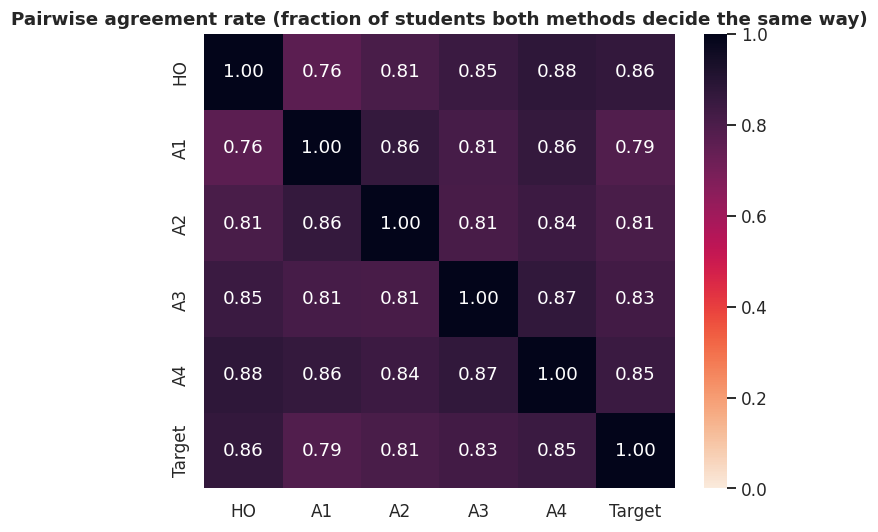

,HO,A1,A2,A3,A4,Target
HO,1.000,0.764,0.806,0.847,0.878,0.864
A1,0.764,1.000,0.862,0.813,0.862,0.788
A2,0.806,0.862,1.000,0.811,0.842,0.808
A3,0.847,0.813,0.811,1.000,0.868,0.828
A4,0.878,0.862,0.842,0.868,1.000,0.848
Target,0.864,0.788,0.808,0.828,0.848,1.000


In [15]:
compare_cols = ['HO'] + algorithms + ['should_recieve_housing']
labels = ['HO', 'A1', 'A2', 'A3', 'A4', 'Target']

agree_matrix = pd.DataFrame(index=labels, columns=labels, dtype=float)
for c1, l1 in zip(compare_cols, labels):
    for c2, l2 in zip(compare_cols, labels):
        agree_matrix.loc[l1, l2] = (house_df[c1] == house_df[c2]).mean()

plt.figure(figsize=(6, 5))
sns.heatmap(agree_matrix.astype(float), annot=True, cmap=SEQUENTIAL_CMAP, vmin=0, vmax=1, fmt='.2f')
plt.title('Pairwise agreement rate (fraction of students both methods decide the same way)')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/5_7_agreement_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

agree_matrix.round(3)

**Interpretation**

The diagonal-adjacent Target column exactly reproduces the accuracy numbers (HO 0.86 ≈ 0.864, A1 0.79 ≈ 0.788, A2 0.81 ≈ 0.808, A3 0.83 ≈ 0.828, A4 0.85 ≈ 0.848), which makes sense, since "agreement with target" is accuracy.

HO's decisions agree most with A4 (0.88) and A3 (0.85), and least with A1 (0.76). This matches everything above: HO leans on urgency, A3/A4 also lean on urgency (unlike A1's pure need-only rule), so HO's pattern naturally resembles A3/A4 more than A1.

A1 and A2 agree with each other most (0.86) among the algorithm pairs, both are need-dominated, so this tracks.

Interestingly, A3 and A4 only agree with each other 0.87,not dramatically higher than they agree with HO, despite both being "complex." This is more evidence they're complex in different ways (commute-driven vs. age-driven) rather than converging on a similar rule.

### Performance of the four algorithms

The metrics come from `02_performance_metrics.ipynb`, so the numbers used here are the same ones reported in section 3.

In [16]:
metrics_df = pd.read_csv(RESULTS_DIR / 'performance_metrics.csv', index_col=0)
performance_summary = metrics_df.loc[algorithms, ["Accuracy", "Precision", "Recall", "F1"]]
performance_summary

,Accuracy,Precision,Recall,F1
Method,,,,
A1,0.788,0.760,0.575,0.655
A2,0.808,0.698,0.793,0.743
A3,0.828,0.804,0.671,0.731
A4,0.848,0.879,0.655,0.750


###  Fairness checks:

We reuse the same two fairness definitions and the same 5 percentage point margin as the fairness section:

- **Predictive parity**: among applicants a method allocates housing to, what fraction genuinely have `should_recieve_housing = 1`?
- **Equality of false negatives (FNR)**: among applicants who genuinely have `should_recieve_housing = 1`, what fraction does the method fail to house?

Both are checked across three groupings `international`, `age_group`, and the combined subgroup (`international` x `age_group`) for **6 checks per algorithm** in total.

In [17]:
house_df['subgroup'] = house_df['international'] + '_' + house_df['age_group']

def predictive_parity(data, decision_col, group_col, target_col='should_recieve_housing'):
    allocated = data[data[decision_col] == 1]
    return allocated.groupby(group_col)[target_col].mean() * 100

def false_negative_rate(data, decision_col, group_col, target_col='should_recieve_housing'):
    positives = data[data[target_col] == 1]
    fn = positives[positives[decision_col] == 0].groupby(group_col).size()
    tp = positives[positives[decision_col] == 1].groupby(group_col).size()
    idx = fn.index.union(tp.index)
    fn = fn.reindex(idx, fill_value=0)
    tp = tp.reindex(idx, fill_value=0)
    return (fn / (fn + tp)) * 100

def passes_margin(values, margin=MARGIN_PERCENT):
    return (values.max() - values.min()) <= margin

group_cols = ['international', 'age_group', 'subgroup']

fairness_rows = []
for algo in algorithms:
    row = {'Algorithm': algo}
    checks = []
    for group_col in group_cols:
        pp = predictive_parity(house_df, algo, group_col)
        fnr = false_negative_rate(house_df, algo, group_col)
        row[f'PP gap ({group_col})'] = round(pp.max() - pp.min(), 1)
        row[f'FNR gap ({group_col})'] = round(fnr.max() - fnr.min(), 1)
        checks.append(passes_margin(pp))
        checks.append(passes_margin(fnr))
    row['fairness checks passed (of 6)'] = sum(checks)
    fairness_rows.append(row)

fairness_df = pd.DataFrame(fairness_rows).set_index('Algorithm')
fairness_checks_passed = fairness_df['fairness checks passed (of 6)']
fairness_df

,PP gap (international),FNR gap (international),PP gap (age_group),FNR gap (age_group),PP gap (subgroup),FNR gap (subgroup),fairness checks passed (of 6)
Algorithm,,,,,,,
A1,0.1,23.0,16.9,4.4,18.6,31.4,2
A2,4.3,24.8,21.8,4.6,26.3,28.8,2
A3,1.4,1.7,13.4,3.7,27.2,20.0,3
A4,5.7,12.2,3.9,34.4,8.8,46.0,1


### Complexity
fit three "surrogate" models of increasing complexity to reproduce each algorithm's own decisions a ,single-feature stump, a depth-3 tree, and a full logistic regression using every feature and use the pattern of their accuracies to assign a complexity label automatically, instead of typing a description by hand.

In [18]:
X = house_df[feature_cols]
X_scaled = StandardScaler().fit_transform(X)

def classify_complexity(stump_acc, logit_acc, simple_threshold=0.95, gap_threshold=0.05, clean_threshold=0.98):
    """Turn the surrogate-model accuracies into a short, automatically-derived label."""
    if stump_acc >= simple_threshold:
        return "simplest (dominated by 1 feature)"
    gap = logit_acc - stump_acc
    if gap < gap_threshold:
        return "moderate (1-2 features)"
    if logit_acc >= clean_threshold:
        return "high, clean (fully captured by a linear combination)"
    return "high, messy (not fully captured even by a linear model)"

complexity_rows = []
for algo in algorithms:
    y = house_df[algo]
    stump = DecisionTreeClassifier(max_depth=1, random_state=RANDOM_STATE).fit(X, y)
    tree3 = DecisionTreeClassifier(max_depth=3, random_state=RANDOM_STATE).fit(X, y)
    logit = LogisticRegression(max_iter=1000).fit(X_scaled, y)

    stump_acc = accuracy_score(y, stump.predict(X))
    tree3_acc = accuracy_score(y, tree3.predict(X))
    logit_acc = accuracy_score(y, logit.predict(X_scaled))

    complexity_rows.append({
        'Algorithm': algo,
        'Stump accuracy': round(stump_acc, 3),
        'Tree(d=3) accuracy': round(tree3_acc, 3),
        'Logistic accuracy': round(logit_acc, 3),
        'complexity character': classify_complexity(stump_acc, logit_acc),
    })

complexity_df = pd.DataFrame(complexity_rows).set_index('Algorithm')
complexity_note = complexity_df['complexity character']
complexity_df

,Stump accuracy,Tree(d=3) accuracy,Logistic accuracy,complexity character
Algorithm,,,,
A1,0.982,0.982,0.980,simplest (dominated by 1 feature)
A2,0.910,0.941,0.946,moderate (1-2 features)
A3,0.819,0.877,0.919,"high, messy (not fully captured even by a line..."
A4,0.858,0.929,0.992,"high, clean (fully captured by a linear combin..."


### Bringing performance, fairness, and complexity together

In [19]:
summary = performance_summary.join(fairness_checks_passed).join(complexity_note)
summary

,Accuracy,Precision,Recall,F1,fairness checks passed (of 6),complexity character
Method,,,,,,
A1,0.788,0.760,0.575,0.655,2,simplest (dominated by 1 feature)
A2,0.808,0.698,0.793,0.743,2,moderate (1-2 features)
A3,0.828,0.804,0.671,0.731,3,"high, messy (not fully captured even by a line..."
A4,0.848,0.879,0.655,0.750,1,"high, clean (fully captured by a linear combin..."


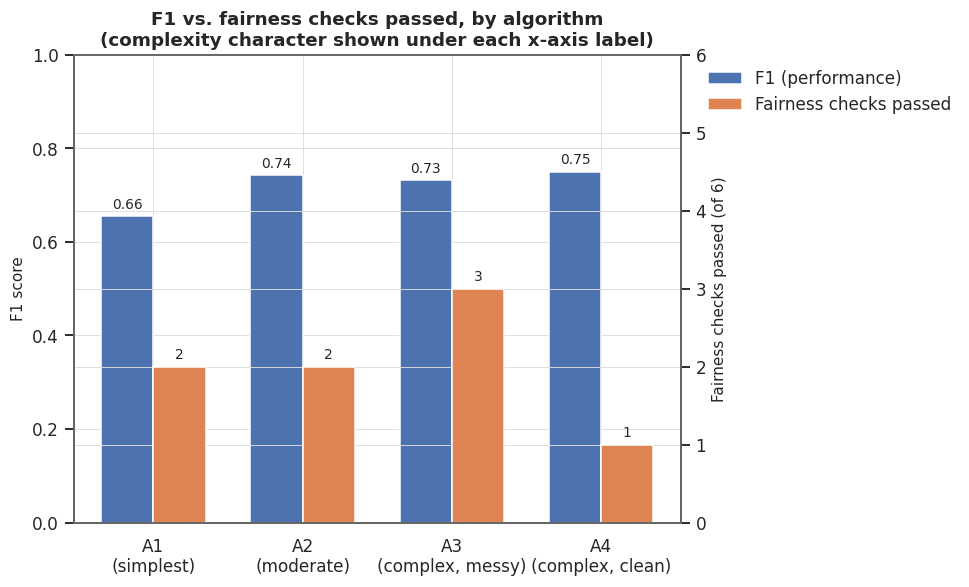

In [20]:
short_complexity = {
    'simplest (dominated by 1 feature)': 'simplest',
    'moderate (1-2 features)': 'moderate',
    'high, messy (not fully captured even by a linear model)': 'complex, messy',
    'high, clean (fully captured by a linear combination)': 'complex, clean',
}
xtick_labels = [f"{a}\n({short_complexity[summary.loc[a, 'complexity character']]})" for a in algorithms]

fig, ax1 = plt.subplots(figsize=(9, 5.5))
x = np.arange(len(algorithms))
width = 0.35

bars1 = ax1.bar(x - width/2, summary.loc[algorithms, 'F1'], width, label='F1 (performance)', color=PRIMARY_COLOR)
ax1.set_ylabel('F1 score')
ax1.set_ylim(0, 1)
ax1.set_xticks(x)
ax1.set_xticklabels(xtick_labels)
ax1.bar_label(bars1, fmt='%.2f', padding=3, fontsize=9)

ax2 = ax1.twinx()
bars2 = ax2.bar(x + width/2, summary.loc[algorithms, 'fairness checks passed (of 6)'], width,
                 label='Fairness checks passed', color=SECONDARY_COLOR)
ax2.set_ylabel('Fairness checks passed (of 6)')
ax2.set_ylim(0, 6)
ax2.bar_label(bars2, fmt='%d', padding=3, fontsize=9)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', bbox_to_anchor=(1.02, 1))

plt.title('F1 vs. fairness checks passed, by algorithm\n(complexity character shown under each x-axis label)')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/5_9_complexity_vs_performance_vs_fairness.png', dpi=300, bbox_inches='tight')
plt.show()

### Discussion: does more complexity lead to better decisions?


- The **simplest** algorithm is not automatically the worst performer, and the **most complex** algorithm is not automatically the best, checking where the highest F1 falls relative to the complexity labels.
- The algorithm with the **most fairness checks passed** is not necessarily the most complex one either, comparing the `fairness checks passed` column against `complexity character` directly.
- The combination our surrogate models could **not** fully explain even with every feature available to a linear model, which is a meaningfully different (and generally more concerning) kind of complexity than one a linear model fully captures.

**Advantages and disadvantages of more complex algorithms in this setting**, to expand on using the numbers above:

- *Advantage*: a well-combined use of more features can improve a specific metric (whether the algorithm with the best Precision or Recall in `performance_summary` is also one of the more complex ones).
- *Disadvantage*: interpretability drops as complexity increases, an algorithm whose stump accuracy is already close to 1.0 can be explained in one sentence; one that needs the full logistic regression to be reproduced well cannot.
- *Disadvantage*: complexity does not protect against unfairness, cross-checking the `fairness checks passed` column against `complexity character` for a concrete counter-example in this dataset.
- *Disadvantage*: a "messy" complex pattern (not fully captured even by a linear model) is the hardest case for a university to audit or defend, since it cannot be reduced to a short, checkable rule even in principle.

In [21]:
summary.to_csv(RESULTS_DIR / 'algorithm_summary.csv')